# **Import the Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# **1. Load Data**

In [4]:
dataset = pd.read_csv('answer_dataset.csv', sep=',')
display(dataset)

,ID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25
0,260001,1,1,1,0,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
1,260002,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,260003,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,0,0,0,0,0
3,260004,1,1,1,1,1,1,1,1,1,...,1,0,0,0,1,1,0,0,0,0
4,260005,0,1,0,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,260996,1,1,1,1,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,0
996,260997,1,1,1,1,1,1,1,1,1,...,1,0,1,1,1,0,1,1,0,0
997,260998,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
998,260999,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


The dataset consists examinee ID and their answer for 25 question items in binary format, 0 indicate wrong answer and 1 indicate true answer. Since the ID column not needed for modelling, it can be dropped and separated from examinee responses matrix.

In [5]:
responses = dataset.drop('ID', axis = 1)

In [6]:
responses.shape

(1000, 25)

There are **1,000 examinees** and **25 question items**.

# **2. Exploratory Data Analysis**

## **2.1 Missing Value Check**

In [7]:
responses.isna().sum()

Q1     0
Q2     0
Q3     0
Q4     0
Q5     0
Q6     0
Q7     0
Q8     0
Q9     0
Q10    0
Q11    0
Q12    0
Q13    0
Q14    0
Q15    0
Q16    0
Q17    0
Q18    0
Q19    0
Q20    0
Q21    0
Q22    0
Q23    0
Q24    0
Q25    0
dtype: int64

In [8]:
print(responses.nunique())

Q1     2
Q2     2
Q3     2
Q4     2
Q5     2
Q6     2
Q7     2
Q8     2
Q9     2
Q10    2
Q11    2
Q12    2
Q13    2
Q14    2
Q15    2
Q16    2
Q17    2
Q18    2
Q19    2
Q20    2
Q21    2
Q22    2
Q23    2
Q24    2
Q25    2
dtype: int64


The responses matrix contains binary outcomes with **no missing values**, making it suitable for IRT modeling.

## **2.2 Raw Score**

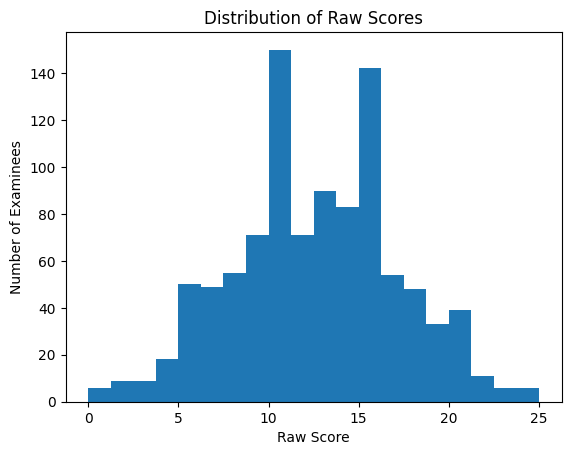

In [9]:
raw_score = responses.sum(axis=1)

plt.hist(raw_score, bins=20)
plt.xlabel("Raw Score")
plt.ylabel("Number of Examinees")
plt.title("Distribution of Raw Scores")
plt.show()

In [10]:
raw_score.describe()

count    1000.000000
mean       12.510000
std         4.563631
min         0.000000
25%         9.000000
50%        13.000000
75%        16.000000
max        25.000000
dtype: float64

The number of correct answers or raw scores achieved by examinees is relatively normally distributed, with a minimum of 0 correct answers and a maximum of 25 correct answers.

## **2.3 Item Difficulty Proxy (P-Value)**

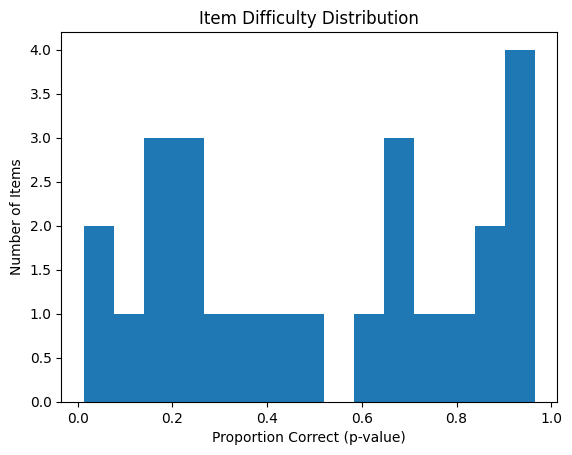

In [11]:
item_p = responses.mean(axis=0)

plt.hist(item_p, bins=15)
plt.xlabel("Proportion Correct (p-value)")
plt.ylabel("Number of Items")
plt.title("Item Difficulty Distribution")
plt.show()

In [12]:
item_p.describe()

count    25.000000
mean      0.500400
std       0.324579
min       0.013000
25%       0.227000
50%       0.465000
75%       0.788000
max       0.965000
dtype: float64

In [13]:
extreme_items = item_p[(item_p < 0.05) | (item_p > 0.95)]
extreme_items

Q1     0.965
Q24    0.013
Q25    0.013
dtype: float64

There are three extreme items (Q1, Q24, and Q25) that were answered correctly by almost all examinees or answered incorrectly by almost all examinees. These will be analyzed further later when the posterior parameters are known.

## **2.4 Examinee Extreme Response Check**

In [14]:
perfect = raw_score == responses.shape[1]
zero = raw_score == 0

perfect.sum(), zero.sum()

(np.int64(1), np.int64(3))

There are 1 examinees that have perfect raw score (25/25) and 3 examinees with zero raw score (0/25).
These response patterns provide limited information for precise ability estimation, resulting in wider posterior intervals for the corresponding parameters.
However, due to their small proportion, the estimation of item parameters remains stable.

# **3. Modelling**

**The Bayesian Item Response Theory (IRT)** approach with a **Two-Parameter Logistic (2PL)** model is used to estimate participant ability and item parameters. The Bayesian approach allows not only point estimates to be obtained, but also the uncertainty of each parameter through posterior distributions.

In [15]:
Y = responses.values
N, J = Y.shape

print('Number of examinees:',N)
print('Number of items:',J)

Number of examinees: 1000
Number of items: 25


## **3.1 Prior Setting**

**$\theta$ (latent ability)** uses a normal distribution to assume that the abilities of examinees follow a normal distribution with a mean of 0 and a standard deviation of 1. $θ_i∼N(0,1)$

**$a$ (item discrimination)** uses a half-normal distribution to force the value of a to remain positive and provide flexibility without allowing extreme negative values. $a_j​∼HalfNormal(1)$

**$b$ (item difficulty)** uses a normal distribution to ensure that the symmetric distribution fits and describes the variation in difficulty levels. $b_j​∼N(0,1)$

The IRT 2PL models the probability of participant $i$ answering question $j$ correctly as:

$P(Y_{ij}=1) = \frac{1}{1+e^{-a_j (\theta_i-b_j)}}$

```python
logits = a * (theta[:, None] - b)
p = pm.math.sigmoid(logits)
```

**Posterior Sampling and Inference**

Parameter inference was performed using Markov Chain Monte Carlo (MCMC) with the NUTS (No-U-Turn Sampler) algorithm.

Bayesian IRT does not produce parameter estimates in the form of closed-form solutions. Therefore, inference is performed by approximating the posterior distribution through sampling methods. Markov Chain Monte Carlo (MCMC) is used to simulate samples from the posterior distribution of participant ability parameters $(\theta)$ and item parameters $(a, b)$, so that estimation uncertainty can be explicitly represented.

The No-U-Turn Sampler (NUTS) algorithm was chosen for its efficiency in high-dimensional parameter spaces such as those found in IRT models. NUTS adaptively determines the length of the sampling path without requiring manual adjustment, resulting in more stable convergence, low autocorrelation, and reliable posterior estimates.

* The parameter `draws=2000` was used to obtain a sufficiently stable posterior sample. A total of 1000 initial iterations were used as a tuning stage to adjust the step size and covariance structure of the sampler.

* The value `target_accept=0.9` was chosen to improve sampling stability and reduce the possibility of divergent transitions.

## **3.2 Model Implementation**

In [16]:
with pm.Model() as irt_model:

    theta = pm.Normal("theta", 0, 1, shape=N)
    a = pm.HalfNormal("a", sigma=1, shape=J)
    b = pm.Normal("b", 0, 1, shape=J)

    logits = a * (theta[:, None] - b)
    p = pm.math.sigmoid(logits)

    y_obs = pm.Bernoulli("y_obs", p=p, observed=Y)

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta, a, b]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 164 seconds.
/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():
We recommend running at least 4 chains for robust computation of convergence diagnostics


# **4. Model Evaluation**

## **4.1 Convergence Results**

In [17]:
summary_ab = az.summary(trace, var_names=["theta", "a", "b"])
display(summary_ab)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],0.148,0.343,-0.483,0.810,0.004,0.008,7926.0,2336.0,1.0
theta[1],0.182,0.342,-0.466,0.794,0.004,0.006,6044.0,3065.0,1.0
theta[2],0.371,0.329,-0.229,0.985,0.004,0.006,6890.0,2977.0,1.0
theta[3],1.006,0.364,0.328,1.673,0.004,0.007,8107.0,2491.0,1.0
theta[4],-1.008,0.341,-1.642,-0.339,0.004,0.006,6032.0,2373.0,1.0
...,...,...,...,...,...,...,...,...,...
b[20],1.737,0.113,1.514,1.937,0.002,0.002,2985.0,2384.0,1.0
b[21],2.044,0.189,1.712,2.409,0.003,0.003,4109.0,3052.0,1.0
b[22],1.445,0.107,1.249,1.650,0.002,0.001,2982.0,3237.0,1.0
b[23],2.706,0.183,2.367,3.040,0.003,0.003,3651.0,2910.0,1.0


Summary table above displays the posterior statistics of the 2PL IRT model parameters, namely participant ability (`theta`), item discrimination (`a`), and item difficulty (`b`), as well as MCMC sampling quality diagnostics.

### General Meaning of the Table
* Each row represents one parameter (e.g., `theta[0]` for participant 0 or `b[20]` for item 20).
* The values shown are not the results of a single estimate, but rather a summary of thousands of posterior samples.

### Interpretation of Main Columns
* **`mean`**: Posterior mean used as a point estimate of the parameter.
For `theta`, this value represents the latent ability of the participant on the logit scale.
* **`sd`**: Posterior standard deviation indicates the level of uncertainty in the estimate. The smaller the value, the more precise the estimate.
* **`hdi_3%` – `hdi_97%`**: Highest Density Interval (94%) is the range of parameter values that are most credible according to the posterior distribution.
* **`ess_bulk` and `ess_tail`**: Effective Sample Size indicates the effectiveness of sampling. A large value indicates a stable estimate.
* **`r_hat`**: MCMC convergence indicator. A value ≈ 1.00 indicates that the model has converged well.

### Conclusion
* All parameters have r_hat ≈ 1.0 and large ESS, so the estimation results are reliable.
* The mean value of `theta` can be used directly as the latent ability score of participants.
* The HDI and `sd` intervals provide additional information about uncertainty, but are not required for reporting final score.

Overall, this table confirms that the 2PL IRT model has been estimated well and the results are ready for further analysis or score transformation.


## **4.2 Posterior Analysis**

### **4.2.1 Trace Plot Parameters `a` and `b`**

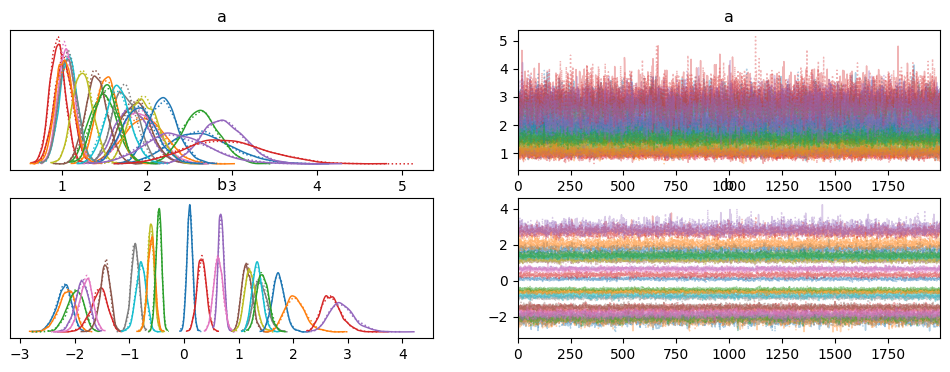

In [18]:
az.plot_trace(trace, var_names=["a", "b"]);

Plot above serves as an MCMC diagnostic.

Each parameter (`a[j]` and `b[j]`) is displayed in two forms:
- **Posterior distribution (left)**
- **MCMC sampling trace (right)**

#### Left Panel: Posterior Distribution

##### Parameter `a` (Discriminative Power)
- The distribution is in positive values, consistent with the `HalfNormal` prior.
- Most of the probability mass is in the range 0.5–3, indicating moderate discriminative power.

Substantive meaning:
- Small `a` value means less discriminative question
- Large `a` value means highly discriminative question  

##### Parameter `b` (Difficulty Level)
- The distribution is in the range −3 to +3.
- Negative `b` value means relatively easy question  
- Positive `b` value means relatively difficult question

#### Right Panel: MCMC Traces

This panel displays parameter values at each sampling iteration.

Characteristics of good traces (and visible in the graph):
- No long-term upward/downward trends
- “Cloud” or “caterpillar” patterns
- Values move randomly around a single region

This indicates:
- The MCMC chain has reached stationarity
- Posterior sampling is functioning properly
- Parameter estimates are reliable

#### Brief Conclusion
- This trace plot shows that the estimates of parameters `a` and `b` are stable and have converged.
- This graph is used for model validation, not to directly report scores or question quality.
- With a good trace and `r_hat ≈ 1`, the posterior results are suitable for further analysis.

### **4.2.2 `a` and `b` Statistics**

In [19]:
summary_a = summary_ab.loc[summary_ab.index.str.startswith("a")]
summary_b = summary_ab.loc[summary_ab.index.str.startswith("b")]

summary_a = summary_a.reset_index()
summary_b = summary_b.reset_index()

summary_a["item"] = summary_a["index"].str.extract(r"\[(\d+)\]").astype(int)
summary_b["item"] = summary_b["index"].str.extract(r"\[(\d+)\]").astype(int)

summary_a = summary_a[["item", "mean", "sd", "hdi_3%", "hdi_97%"]]
summary_b = summary_b[["item", "mean", "sd", "hdi_3%", "hdi_97%"]]

summary_a['HDI width'] = summary_a['hdi_97%'] - summary_a['hdi_3%']
summary_b['HDI width'] = summary_b['hdi_97%'] - summary_b['hdi_3%']

print('a parameter:')
display(summary_a)
print('b parameter:')
display(summary_b)

a parameter:


,item,mean,sd,hdi_3%,hdi_97%,HDI width
0,0,2.637,0.360,2.032,3.366,1.334
1,1,1.974,0.241,1.511,2.396,0.885
2,2,1.486,0.158,1.193,1.780,0.587
3,3,1.014,0.107,0.799,1.198,0.399
4,4,1.827,0.198,1.438,2.183,0.745
5,5,1.862,0.180,1.524,2.182,0.658
6,6,1.925,0.210,1.543,2.321,0.778
7,7,1.737,0.148,1.454,2.005,0.551
8,8,1.958,0.164,1.651,2.255,0.604
9,9,1.073,0.103,0.872,1.255,0.383


b parameter:


,item,mean,sd,hdi_3%,hdi_97%,HDI width
0,0,-2.210,0.141,-2.483,-1.961,0.522
1,1,-2.157,0.155,-2.470,-1.898,0.572
2,2,-1.992,0.152,-2.285,-1.725,0.560
3,3,-1.560,0.152,-1.859,-1.300,0.559
4,4,-1.873,0.127,-2.115,-1.639,0.476
5,5,-1.446,0.096,-1.631,-1.271,0.360
6,6,-1.795,0.121,-2.030,-1.576,0.454
7,7,-0.900,0.073,-1.047,-0.772,0.275
8,8,-0.608,0.060,-0.718,-0.493,0.225
9,9,-0.790,0.094,-0.962,-0.614,0.348


In [20]:
summary_a.describe()

,item,mean,sd,hdi_3%,hdi_97%,HDI width
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,12.000000,1.753600,0.185560,1.409080,2.098440,0.689360
std,7.359801,0.601675,0.096378,0.462807,0.763407,0.354906
min,0.000000,0.944000,0.091000,0.778000,1.116000,0.338000
25%,6.000000,1.241000,0.118000,1.035000,1.475000,0.440000
50%,12.000000,1.737000,0.158000,1.438000,2.005000,0.587000
75%,18.000000,1.974000,0.210000,1.627000,2.396000,0.778000
max,24.000000,2.933000,0.473000,2.416000,3.811000,1.735000


In [21]:
summary_b.describe()

,item,mean,sd,hdi_3%,hdi_97%,HDI width
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,12.000000,0.052320,0.112320,-0.159160,0.258320,0.417480
std,7.359801,1.576819,0.046396,1.566673,1.605602,0.169977
min,0.000000,-2.210000,0.051000,-2.483000,-1.961000,0.189000
25%,6.000000,-1.446000,0.085000,-1.631000,-1.271000,0.320000
50%,12.000000,0.106000,0.104000,0.010000,0.203000,0.388000
75%,18.000000,1.347000,0.141000,1.163000,1.536000,0.522000
max,24.000000,2.903000,0.233000,2.503000,3.362000,0.859000


### **4.2.3 Posterior Analysis for `extreme_items`**

| `extreme_items` | `P-Value` | `a_mean` | `a HDI_width` | `b_mean` | `b HDI_width`|
| -------- | -------- | -------- | -------------- | --------- | --------- |
| Q1 | 0.965 | 2.637 | 1.334 | -2.210 | 0.522 |
| Q24 | 0.013 | 2.933 | 1.735 | 2.706 | 0.673 |
| Q25 | 0.013 | 2.357 | 1.439 | 2.903 | 0.859 |

Items 1, 24, and 25 were retained despite showing extreme response tendencies because their parameter estimates indicated a meaningful psychometric role in the examination.

* Item 1, characterized by a very high tendency for correct responses, shows a very negative difficulty parameter with relatively narrow posterior uncertainty, indicating stable estimation and effective discrimination among participants with low ability.
* Items 24 and 25 function as highly difficult items targeting the upper end of the ability distribution. Both items show high discrimination parameter values and sensitivity to small differences at high ability levels, while their posterior uncertainty indicates a limited number of informative response patterns on extreme items. These characteristics are recognized as natural consequences of items designed to measure ability extremes.

Retaining these items maintains the test's ability to distinguish examinees across the entire ability range and prevents compression of ability estimates at the lower and upper ends of the distribution range.

### **4.2.4 Item Characteristic Curves**

The Item Characteristic Curve (ICC) describes the relationship between the latent ability of test takers $(\theta)$ and the probability of answering a question correctly.

Mathematically, the ICC in the 2PL model is formulated as:
$P(X = 1 \mid \theta) = \frac{1}{1 + e^{\big(-a(\theta - b)\big)}}$

The ICC curve is sigmoidal, where:
- The horizontal axis represents latent ability $(\theta)$
- The vertical axis represents the probability of answering correctly.

The interpretation of ICC is done by considering:
- The horizontal position of the curve, which is determined by the parameter $b$ (the further to the right, the more difficult the question),
- The slope of the curve around point $b$, which is determined by the parameter $a$ (the steeper, the higher the discriminating power of the question).

Since Bayesian inference yields posterior distributions rather than point estimates, examinee ability was summarized using **posterior means** for reporting purposes.

In [22]:
theta_mean = trace.posterior["theta"].mean(dim=("chain", "draw")).values
a_mean = trace.posterior["a"].mean(dim=("chain", "draw")).values
b_mean = trace.posterior["b"].mean(dim=("chain", "draw")).values

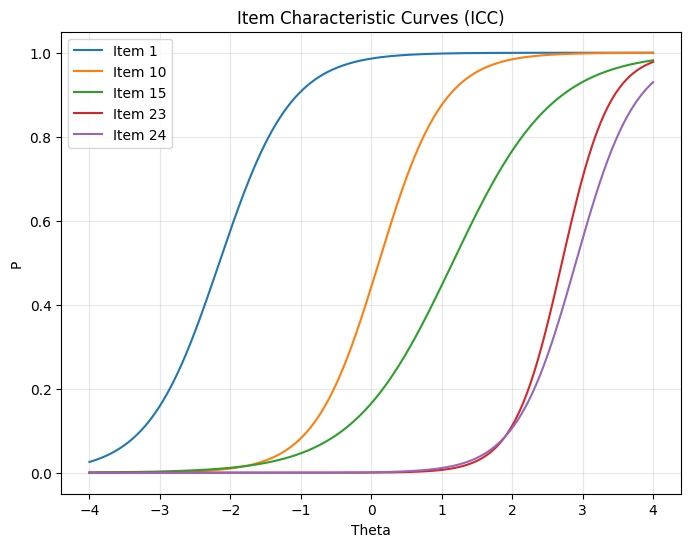

In [23]:
theta_grid = np.linspace(-4, 4, 300)

def icc(theta, a, b):
    return 1 / (1 + np.exp(-a * (theta - b)))

items_to_plot = [1, 10, 15, 23, 24]

plt.figure(figsize=(8, 6))

for j in items_to_plot:
    p = icc(theta_grid, a_mean[j], b_mean[j])
    plt.plot(theta_grid, p, label=f"Item {j}")

plt.xlabel("Theta")
plt.ylabel("P")
plt.title("Item Characteristic Curves (ICC)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The graph above only shows the ICC for 5 items as samples. It can be seen that the purple curve (item 24) is on the far right and red curve (item 23) is the steepest curve. This indicates that $b$ or the difficulty level of this item is relatively higher and has good discriminating power. On the other hand, the blue curve (item 1) is on the far left and appears more flat than others. This indicates that item 1 is an easy question with low discriminating power.

### **4.2.5 Item Information Curves**

The Item Information Curve (IIC) shows how much information a question provides
in estimating the latent ability of test takers $(\theta)$ at various ability levels.
In IRT, information is directly related to the accuracy of estimates. The greater the information at a given value of $(\theta)$, the smaller the uncertainty of ability estimates around that point.

For the 2-Parameter Logistic (2PL) model, the item information function is formulated as:
$I(\theta) = a^2 \cdot P(\theta) \cdot \big(1 - P(\theta)\big)$

The IIC curve is generally bell-shaped and peaks around the item difficulty value $(b)$,
which means that an item is most informative for examinees whose ability is close to its difficulty level.

How to read the IIC:
- The height of the curve indicates how much the item contributes to the estimation of θ,
- The position of the peak indicates the ability range where the item is most effective,
- Items with high discrimination ($a$ is large) produce a higher and narrower information curve,
  making them very effective in distinguishing participants around the value of b.

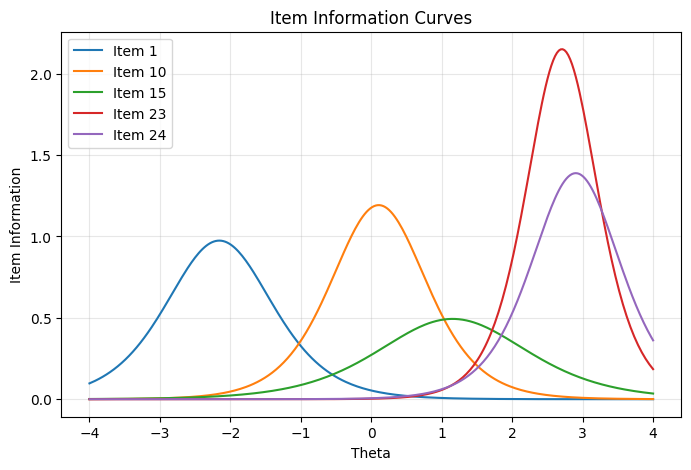

In [24]:
J = len(a_mean)

def item_information(theta, a, b):
    p = 1 / (1 + np.exp(-a * (theta - b)))
    return a**2 * p * (1 - p)

IIF = np.zeros((J, len(theta_grid)))

for j in range(J):
    IIF[j, :] = item_information(theta_grid, a_mean[j], b_mean[j])

items_to_plot = [1, 10, 15, 23, 24]

plt.figure(figsize=(8, 5))
for j in items_to_plot:
    plt.plot(theta_grid, IIF[j], label=f"Item {j}")

plt.xlabel("Theta")
plt.ylabel("Item Information")
plt.title("Item Information Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In the graph above, each curve reaches its peak around a value of $\theta$ that is close to the difficulty parameter $(b)$ of that item. Items with curve peaks at low $\theta$ values (e.g., Item 1) provide optimal information for participants with low abilities, while items with peaks at high $\theta$ values (e.g., Items 23 and 24) are most informative for distinguishing participants with high abilities. The height of the curve peak is also influenced by the discrimination parameter $(a)$. A larger value of $a$ results in higher information and a sharper curve.


### **4.2.6 Theta Statistic**

In the Bayesian model, the estimated ability parameter $(\theta)$ is influenced by the observed response and the chosen prior distribution.
Although different priors can cause small variations in the posterior estimate, especially for extreme response patterns, the overall ability estimate remains stable when the data is sufficiently informative.
The high sensitivity of $(\theta)$ to prior specifications indicates weak identification or limited information in the observed response.

In [25]:
summary_theta = summary_ab.loc[summary_ab.index.str.startswith("theta")]

summary_theta = summary_theta.reset_index()
summary_theta["ID"] = summary_theta["index"].str.extract(r"\[(\d+)\]").astype(int)

summary_theta = summary_theta[["ID", "mean", "sd", "hdi_3%", "hdi_97%"]]
display(summary_theta)

,ID,mean,sd,hdi_3%,hdi_97%
0,0,0.148,0.343,-0.483,0.810
1,1,0.182,0.342,-0.466,0.794
2,2,0.371,0.329,-0.229,0.985
3,3,1.006,0.364,0.328,1.673
4,4,-1.008,0.341,-1.642,-0.339
...,...,...,...,...,...
995,995,-0.561,0.335,-1.191,0.056
996,996,1.578,0.387,0.832,2.304
997,997,0.567,0.349,-0.111,1.211
998,998,-0.941,0.350,-1.606,-0.299


In [26]:
summary_theta.describe()

,ID,mean,sd,hdi_3%,hdi_97%
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,-0.000322,0.351943,-0.659371,0.658508
std,288.819436,0.950387,0.019681,0.937834,0.969669
min,0.000000,-2.830000,0.318000,-3.704000,-1.946000
25%,249.750000,-0.656750,0.340000,-1.298250,-0.017250
50%,499.500000,0.000000,0.346000,-0.637000,0.645000
75%,749.250000,0.644750,0.357000,-0.004750,1.295250
max,999.000000,3.085000,0.480000,2.259000,4.018000


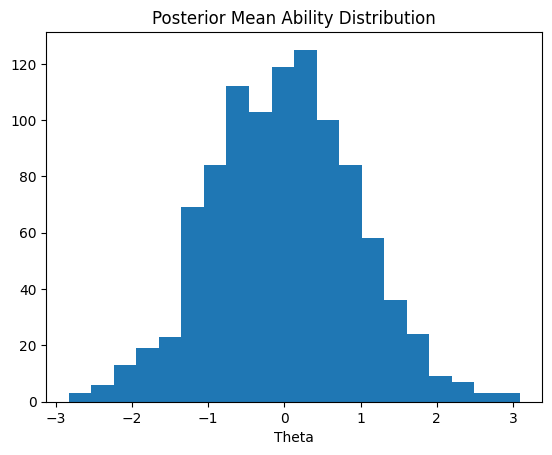

In [27]:
plt.hist(theta_mean, bins=20)
plt.title("Posterior Mean Ability Distribution")
plt.xlabel("Theta")
plt.show()

The posterior ability estimate $(\theta)$ slightly exceeds +3, indicating that the model successfully identifies highly informative response patterns at the ends of the ability scale. This behavior is expected in well-designed IRT models when item difficulty $(b)$ covers a wide range and the discrimination parameter $(a)$ is sufficiently strong.

# **5. Scoring**

Theta $(\theta)$ obtained from the IRT model is not sufficiently informative for lay people, including examinees. Therefore, scoring is based on the latent ability of examinees $(\theta)$ for the purpose of transparency in reporting exam results to examinees. Based on $\theta$, this score reflects the relative ability of a examinee compared to the examination population.

Theta estimates are **linearly transformed** to a reported score scale for interpretability. A linear transformation is performed to map the value of $\theta$ to a more familiar and communicative score scale without changing the order or relative distance between participants.

The linear transformation maintains monotonicity so that examinee with higher $\theta$ still receive higher scores. In addition, this transformation does not change the psychometric information contained in the $\theta$ estimate, but only changes the representation of the scale.

In [28]:
irt_score = 500 + 100 * theta_mean

Since the latent ability parameter is already standardized through model identification constraints, final scores are obtained via a linear transformation of posterior mean ability estimates without additional z-score normalization.

In [29]:
comparison_df = pd.DataFrame({
    "Raw_Score": raw_score,
    "Theta": theta_mean,
    "IRT_Score": irt_score
})

comparison_df.sort_values("IRT_Score", ascending=False).head(25)

,Raw_Score,Theta,IRT_Score
209,25,3.085134,808.513396
847,24,2.882150,788.215017
478,24,2.810791,781.079054
654,24,2.653249,765.324904
179,24,2.644607,764.460669
234,24,2.641187,764.118742
762,23,2.468687,746.868686
755,22,2.402757,740.275729
460,23,2.380326,738.032605
474,23,2.346853,734.685268


Although some examinees exhibit identical response patterns (e.g., perfect or zero scores),
their estimated abilities are not exactly identical.
In a Bayesian IRT framework, ability parameters are inferred as posterior distributions rather than fixed values.
For extreme response patterns, the likelihood provides limited information,
leading to posterior estimates that are influenced by the prior and sampling variability.
The resulting differences are minor and reflect uncertainty rather than meaningful ability differences.

In [30]:
comparison_df.describe()

,Raw_Score,Theta,IRT_Score
count,1000.000000,1000.000000,1000.000000
mean,12.510000,-0.000333,499.966673
std,4.563631,0.950396,95.039619
min,0.000000,-2.830421,216.957923
25%,9.000000,-0.656509,434.349071
50%,13.000000,0.000058,500.005802
75%,16.000000,0.644506,564.450582
max,25.000000,3.085134,808.513396


It can be seen in the table that the highest $\theta$ is around 3.08, resulting in a final score of around 808.51, while the lowest $\theta$ is -2.83, resulting in a final score of around 216.97.

Although the linear transformation uses a scaling factor of 100, the resulting score distribution reflects the empirical variability of posterior ability estimates. Since the posterior standard deviation of $\theta$ is approximately 0.95, the final score standard deviation is correspondingly around 95.

## **5.1 Score Interpretation**

The final score reflects the examinee's relative position in the population ability distribution. It does not directly represent the number of correct answers, but rather the level of latent ability estimated based on response patterns across items.

Score differences between examinees reflect differences in ability adjusted for item characteristics, including difficulty and discrimination. Therefore, two examinees with the same raw score may have different final scores. The final score should be interpreted as a more fair and informative measure of comparative ability than the raw score, especially when items vary in difficulty.